# Introduction to the Data

This data specifically contains all of the neurons in the entorhinal cortex (EC), extracted from the following source:
https://alleninstitute.github.io/abc_atlas_access/descriptions/MERFISH-C57BL6J-638850-imputed.html

For more details, see the original paper:
https://www.nature.com/articles/s41586-023-06812-z

In [38]:
# Import packages for data manipulation and visualization
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import packages for neuron visualizations

from brainrender import Scene
from brainrender.actors import Points

import vedo
vedo.settings.default_backend= 'vtk'

#####
# Load Libraries
from sklearn.linear_model import LogisticRegression

# Other necessary packages
from sklearn.preprocessing import StandardScaler # scaling features
from sklearn.pipeline import make_pipeline           # combining classifier steps
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

from sklearn.model_selection import GridSearchCV, KFold, StratifiedKFold 
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, KFold, StratifiedKFold
from sklearn.model_selection import train_test_split

# data manipulation 
import pandas as pd
import numpy as np

# plotting
import seaborn as sns
import matplotlib.pyplot as plt

# neuron visualizations
from brainrender import Scene
from brainrender.actors import Points

import vedo
vedo.settings.default_backend= 'vtk'

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster import hierarchy
from sklearn.metrics import make_scorer

import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_samples, silhouette_score
###
# Add any additional libraries or submodules below

# Data libraries
import pandas as pd
import numpy as np

# Plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns


# sklearn modules
import sklearn

#Pipeline
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, TargetEncoder, FunctionTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score,classification_report, ConfusionMatrixDisplay
from sklearn.metrics import  RocCurveDisplay, roc_auc_score, accuracy_score, PrecisionRecallDisplay
from sklearn.model_selection import GridSearchCV, KFold, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.compose import make_column_transformer
from sklearn.utils import resample
from sklearn.ensemble import RandomForestClassifier

#Statistical libraries
from scipy.stats import chi2_contingency
#Custom function to computer the within cluster variance (will be used as custom scoring method for spectral clustering)
def compute_wcv(labels, X):
    wcv = 0
    for cluster in np.unique(labels):
        X_cluster = X[labels==cluster]
        centroid = np.mean(X_cluster,axis=0)
        wcv_cluster = ((X_cluster - centroid)**2).sum().sum()
        wcv += wcv_cluster
    return wcv

def spectral_scorer_wcv(estimator, X, y=None):
    labels = estimator.fit_predict(X)
    wcv = compute_wcv(labels, X)
    return -wcv

def spectral_scorer_sil(estimator, X, y=None):
    labels = estimator.fit_predict(X)
    score =  silhouette_score(X,labels,metric="cosine")
    return -score


The EC data is stored in an `anndata` object: https://anndata.scverse.org/en/stable/. 
The `anndata` format is designed for the storage of Annotated Matrix data. 
It is centered around a core matrix - `anndata.X` - in which rows are cells (observations) and genes are columns (variables).
Importantly, both the rows and the columns of this matrix are indexed, and have associated metadata.

- `anndata.obs` is a dataframe containing all cellular metadata. Rows = Cells, Columns = Metadata (e.g. cell type)
- `anndata.var` is a dataframe containing all gene-level metadata. Rows = Genes, Columns = Metadata (e.g. alternative gene symbols)


In [39]:
# load EC data (imputed MERFISH) object

source = "ec_obj_imputed_log2.h5ad"

ec_data = ad.read_h5ad(source)

print(ec_data)

AnnData object with n_obs × n_vars = 48615 × 8460
    obs: 'brain_section_label', 'class', 'subclass', 'supertype', 'structure', 'substructure', 'x_ccf', 'y_ccf', 'z_ccf'
    var: 'gene_symbol'


Let's start by taking a brief look at the core matrix of gene expression and plot some basic statistics (mean vs standard deviation).

In [40]:
# Let's take a brief look at the core matrix
ec_data.X[0:5]


array([[0.00397 , 0.137   , 0.1438  , ..., 0.      , 0.      , 0.      ],
       [0.005955, 0.1145  , 0.1251  , ..., 0.      , 0.      , 0.      ],
       [0.00397 , 0.2433  , 0.1274  , ..., 0.      , 0.      , 0.      ],
       [0.001986, 0.2413  , 0.1993  , ..., 0.      , 0.      , 0.      ],
       [0.00397 , 0.0409  , 0.02443 , ..., 0.      , 0.      , 0.      ]],
      shape=(5, 8460), dtype=float16)

In [41]:
# Create a pandas DataFrame from the AnnData object for easier manipulation
df = pd.DataFrame(ec_data.X, columns=ec_data.var_names)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48615 entries, 0 to 48614
Columns: 8460 entries, ENSMUSG00000026676 to ENSMUSG00000029695
dtypes: float16(8460)
memory usage: 784.5 MB


In [42]:
df.head(5)

c:\Users\ricca\miniconda3\Lib\site-packages\pandas\io\formats\format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


c:\Users\ricca\miniconda3\Lib\site-packages\pandas\io\formats\format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


gene_identifier,ENSMUSG00000026676,ENSMUSG00000024517,ENSMUSG00000029361,ENSMUSG00000062372,ENSMUSG00000055639,ENSMUSG00000021662,ENSMUSG00000047945,ENSMUSG00000055761,ENSMUSG00000068735,ENSMUSG00000021010,...,ENSMUSG00000032057,ENSMUSG00000072762,ENSMUSG00000111058,ENSMUSG00000029505,ENSMUSG00000034187,ENSMUSG00000048520,ENSMUSG00000115186,ENSMUSG00000112441,ENSMUSG00000029811,ENSMUSG00000029695
0,0.003971,0.136963,0.143799,0.001706,10.835938,1.180664,3.697266,7.769531,3.406250,0.420410,...,0.005730,0.371826,0.0,4.531250,5.925781,0.021332,0.669434,0.0,0.0,0.0
1,0.005955,0.114502,0.125122,0.001706,10.781250,1.252930,3.361328,7.515625,3.367188,0.419678,...,0.009552,0.389893,0.0,4.585938,5.992188,0.021332,0.662109,0.0,0.0,0.0
2,0.003971,0.243286,0.127441,0.001706,10.765625,0.996094,3.572266,7.726562,3.218750,0.572266,...,0.001910,0.593750,0.0,4.300781,5.781250,0.012802,0.364990,0.0,0.0,0.0
3,0.001986,0.241333,0.199341,0.001706,10.742188,0.989258,3.179688,7.703125,3.396484,0.418701,...,0.005730,0.562988,0.0,4.468750,5.984375,0.017059,0.535156,0.0,0.0,0.0
4,0.003971,0.040894,0.024429,0.000000,10.523438,0.969727,2.427734,7.250000,2.445312,0.195068,...,0.005730,0.498291,0.0,4.691406,6.117188,0.046936,0.682129,0.0,0.0,0.0


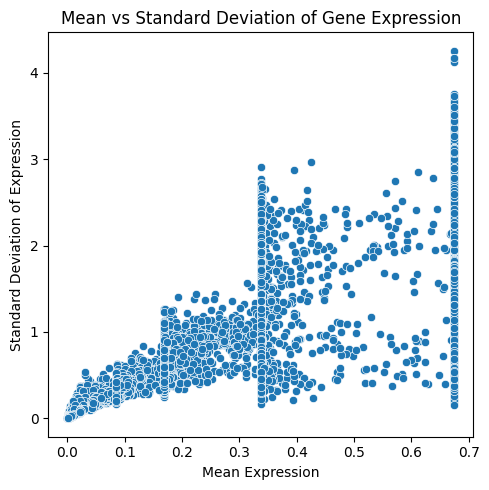

In [43]:
# Use pandas describe function to get summary statistics of the data and plot mean expression and variance for each gene    
mean_df = df.mean()
std_df = df.std()

figs, axes = plt.subplots(1, 1, figsize=(5, 5))
sns.scatterplot(x=mean_df, y=std_df, ax=axes)
axes.set_xlabel("Mean Expression")
axes.set_ylabel("Standard Deviation of Expression")
axes.set_title("Mean vs Standard Deviation of Gene Expression")
plt.tight_layout()
plt.show()


We have added a variety of cellular metadata to this object.
The `class`, `subclass` and `supertype` metadata variables annotate each cell with a canonical transcriptomic cell type (based on the cell taxonomy developed by the Allen Brain Institute). 
These metadata variables are nested. Classes contain subclasses, and subclasses contain supertypes.

The `x_ccf`, `y_ccf`, and `z_ccf` variables together map the location of each cell in the (base 25um) Common Coordinate Framework which describes the average mouse brain.
X-axis = anterior (front of the brain) - posterior (back of the brain)
Y-axis = dorsal (top of the brain) - ventral (bottom of the brain)
Z-Axis = left to right 

The `structure` and `substructure` metadata variables assign each cell to a brain region, based on the aforementioned CCF coordinates.

First, lets visualize all of our neurons within the mouse brain.

In [44]:
# # Visualize neurons in 3D using brainrender
# neurons = np.array(ec_data.obs[['x_ccf', 'y_ccf', 'z_ccf']])
# points = Points(neurons, radius=20, colors="orange")

# # Create a brainrender scene
# scene = Scene(atlas_name="allen_mouse_25um", title="Visualizing EC Neurons in 3D")

# # add neurons
# scene.add(points)

# # add canonial MEC and LEC region meshes
# lec = scene.add_brain_region("ENTl", alpha=0.1, color="blue")
# mec = scene.add_brain_region("ENTm", alpha=0.1, color="blue")

# scene.add(lec)
# scene.add(mec)

# # Render
# scene.render()

As expected, all of our cells are within the Entorhinal Cortex.
We can also see a consequence of the experiment here. This data was generated by taking coronal slices from the brain, at specific intervals (in this case 200um), and sequencing the cells within.
The cells are therefore organized in discrete slices along the X-axis (anterior-posterior) within the brain.

Now we produce a few more brainrender visualizations, grouping and colouring cells according to different metadata values each time.
For the sake of clarity, we first extract the cell metadata information as a separate table.

In [45]:
cell_metadata = ec_data.obs
cell_metadata.head(n = 5)

,brain_section_label,class,subclass,supertype,structure,substructure,x_ccf,y_ccf,z_ccf
cell_label,,,,,,,,,
1018093344100490327-3,C57BL6J-638850.19,03 OB-CR Glut,036 HPF CR Glut,0135 HPF CR Glut_1,ENTm,ENTm1,10187.352431,3058.025140,8767.202589
1018093343102220029,C57BL6J-638850.24,03 OB-CR Glut,036 HPF CR Glut,0135 HPF CR Glut_1,ENTm,ENTm2,9552.388366,5703.533695,2455.997510
1019171912100520248,C57BL6J-638850.27,03 OB-CR Glut,036 HPF CR Glut,0135 HPF CR Glut_1,ENTm,ENTm3,8960.087708,6176.805722,2417.074366
1017092617102590124,C57BL6J-638850.25,03 OB-CR Glut,036 HPF CR Glut,0135 HPF CR Glut_1,ENTm,ENTm3,9610.027924,5217.053289,8901.322743
1018093343100500636-1,C57BL6J-638850.24,03 OB-CR Glut,036 HPF CR Glut,0135 HPF CR Glut_1,ENTm,ENTm1,9865.030167,4454.612706,8784.204463


C:\Users\ricca\AppData\Local\Temp\ipykernel_33732\2266805309.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=90, ha='right')
C:\Users\ricca\AppData\Local\Temp\ipykernel_33732\2266805309.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=90, ha='right')
C:\Users\ricca\AppData\Local\Temp\ipykernel_33732\2266805309.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=90, ha='right')


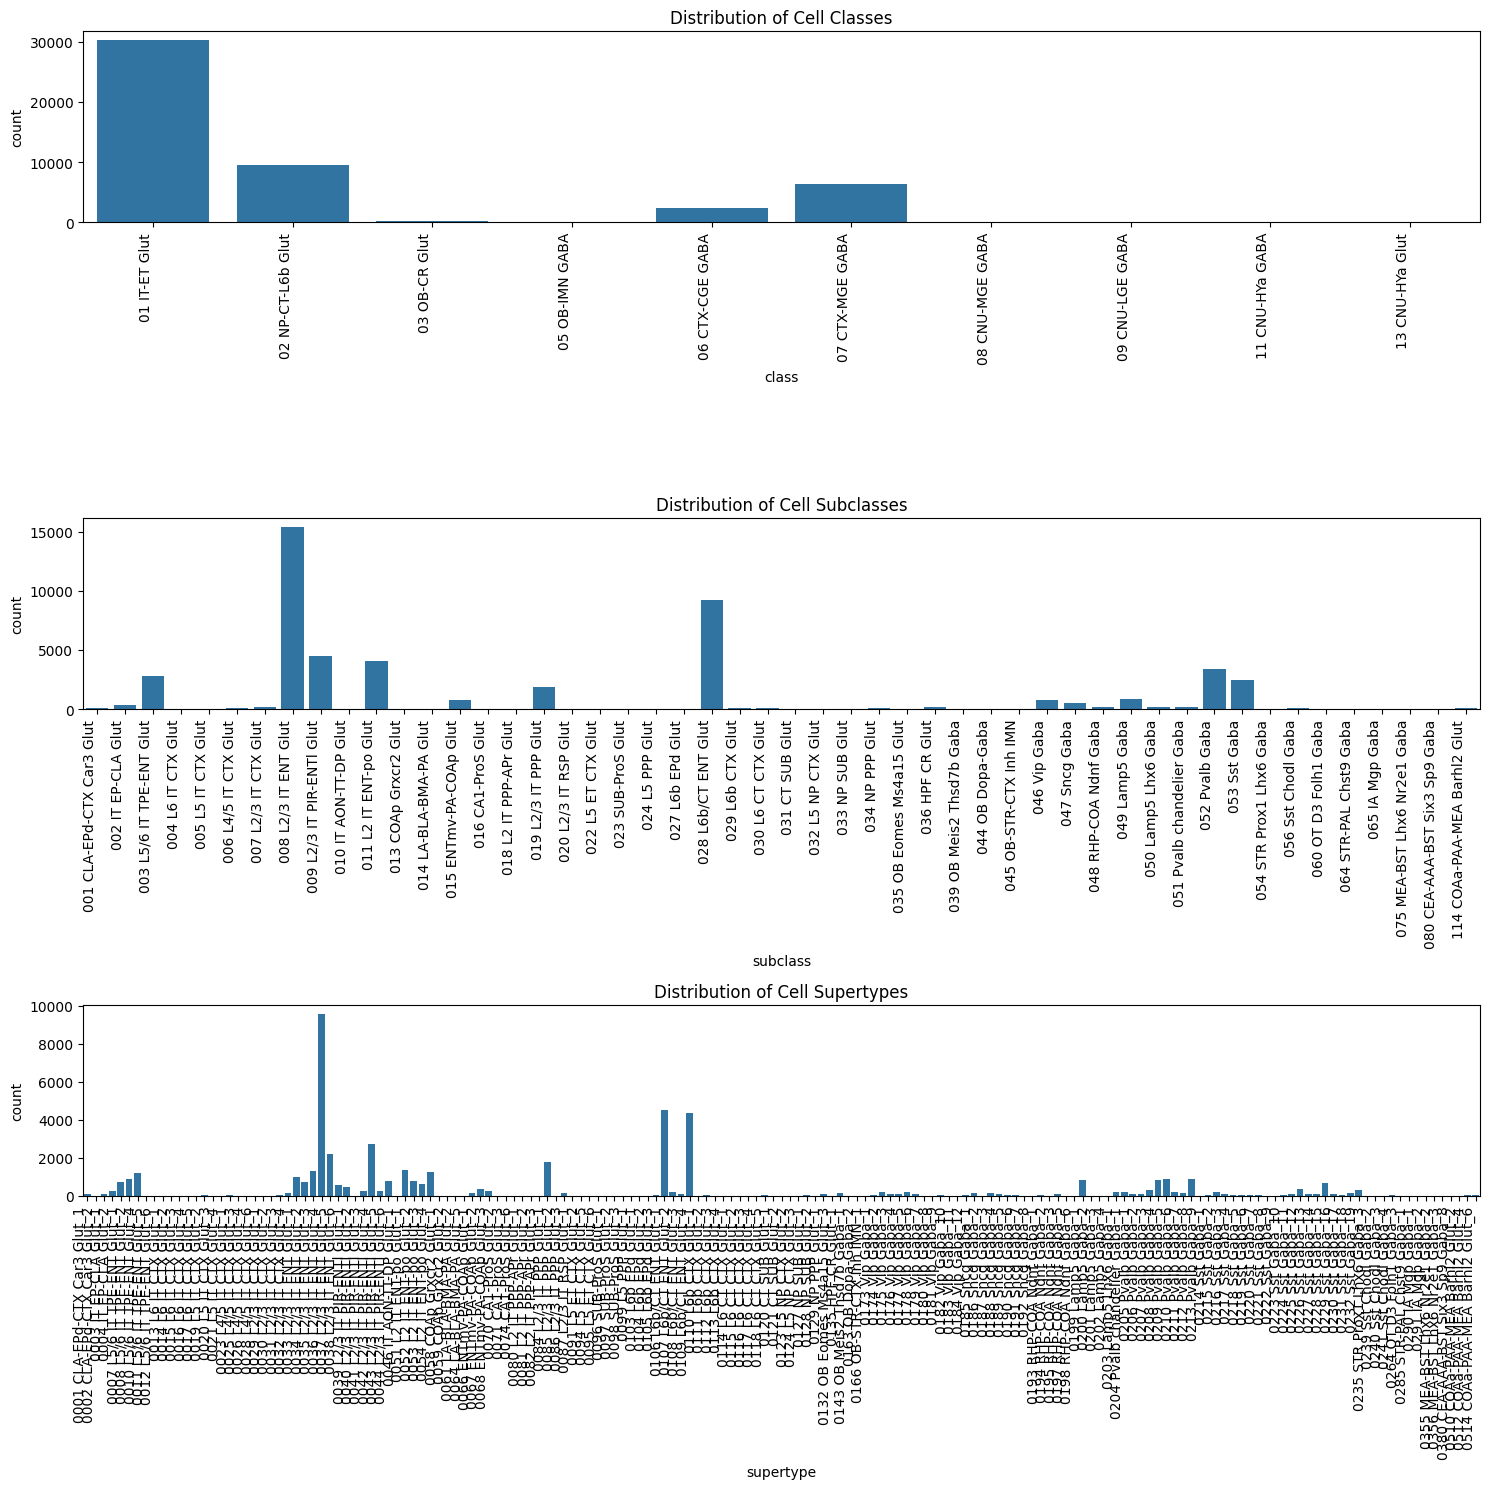

In [46]:
# Visualize the distribution of cell types in the dataset
figs, axes = plt.subplots(3, 1, figsize=(15, 15))
sns.countplot(x='class', data=cell_metadata, ax=axes[0])
axes[0].set_title("Distribution of Cell Classes")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=90, ha='right')
sns.countplot(x='subclass', data=cell_metadata, ax=axes[1])
axes[1].set_title("Distribution of Cell Subclasses")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=90, ha='right')
sns.countplot(x='supertype', data=cell_metadata, ax=axes[2])
axes[2].set_title("Distribution of Cell Supertypes")
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=90, ha='right') 
plt.tight_layout()
plt.show()

In [47]:
# # Colour by Region

# mec_cells = cell_metadata[cell_metadata["structure"] == "ENTm"]
# mec_coords = np.array(mec_cells[["x_ccf", "y_ccf", "z_ccf"]])
# mec_points = Points(mec_coords, radius=20, colors="orange")

# lec_cells = cell_metadata[cell_metadata["structure"] == "ENTl"]
# lec_coords = np.array(lec_cells[["x_ccf", "y_ccf", "z_ccf"]])
# lec_points = Points(lec_coords, radius=20, colors="green")

# # Create a brainrender scene
# scene = Scene(atlas_name="allen_mouse_25um", title="EC Neurons (Coloured by Region)")

# # add neurons
# scene.add(mec_points)
# scene.add(lec_points)

# # add canonial MEC and LEC region meshes
# lec = scene.add_brain_region("ENTl", alpha=0.1, color="blue")
# mec = scene.add_brain_region("ENTm", alpha=0.1, color="blue")

# scene.add(lec)
# scene.add(mec)

# # Render
# scene.render()


In [48]:
# # Visualize specific cell types - in this case the cell types enriched in EC L5a.

# # 034 NP PPP Glut: cell type enriched in medial EC L5a.
# np_data = cell_metadata[cell_metadata["subclass"] == '034 NP PPP Glut']
# np_coords = np.array(np_data[["x_ccf", "y_ccf", "z_ccf"]])
# np_points = Points(np_coords, radius = 20, colors="blue")

# # 003 L5/6 IT TPE-ENT Glut: cell type enriched in lateral EC L5a
# l56_data = cell_metadata[cell_metadata["subclass"] == '003 L5/6 IT TPE-ENT Glut']
# l56_coords =np.array(l56_data[["x_ccf", "y_ccf", "z_ccf"]])
# l56_points = Points(l56_coords, radius = 20, colors="green")

# # Create a brainrender scene
# scene = Scene(atlas_name="allen_mouse_25um", title="EC Neurons (Coloured by Cell Type)")

# # add neurons
# scene.add(np_points)
# scene.add(l56_points)

# # add canonial MEC and LEC region meshes
# lec = scene.add_brain_region("ENTl", alpha=0.1, color="blue")
# mec = scene.add_brain_region("ENTm", alpha=0.1, color="blue")

# scene.add(lec)
# scene.add(mec)

# # Render
# scene.render()


There are many, many supertypes in this dataset - so much so that trying to colour by supertype overwhelms SCANPY and results in every cell being assigned the same, default grey colour.

Here we want to: apply the classification algorithm and generate the snr-like cluster labels. Cluster the merfish dataset base on gene expression. Compare this clustering with the snr-like labels.

----------------My Notebook--------------------

In [49]:
import joblib

svm_model_snr = joblib.load("svm_classifier.pkl")



In [50]:
#fetch the part of the database containing the coordinates of the cells in merfish db

cell_metadata.head()

#should have 48615 rows

cell_metadata.info() #ok

<class 'pandas.core.frame.DataFrame'>
Index: 48615 entries, 1018093344100490327-3 to 1017092617102930254
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   brain_section_label  48615 non-null  category
 1   class                48615 non-null  category
 2   subclass             48615 non-null  category
 3   supertype            48615 non-null  category
 4   structure            48615 non-null  category
 5   substructure         48615 non-null  category
 6   x_ccf                48615 non-null  float64 
 7   y_ccf                48615 non-null  float64 
 8   z_ccf                48615 non-null  float64 
dtypes: category(6), float64(3)
memory usage: 2.8+ MB


In [51]:
#get snr labels using our classification algorithm
coords = cell_metadata.copy()

#Get cols to keep
cols_to_keep = []
for col in coords.columns:
    if "ccf" in col:
        cols_to_keep.append(col)

#Get a dataframe containing the coordinates only
coords = coords.drop(columns=[cols for cols in coords if cols not in cols_to_keep])

#rename the columns to match snr database
coords.columns = ["x", "y", "z"]

In [52]:
#predict the labels
snr_labels = svm_model_snr.predict(coords)

{0: 39999, 1: 4857, 2: 3759}


<Axes: >

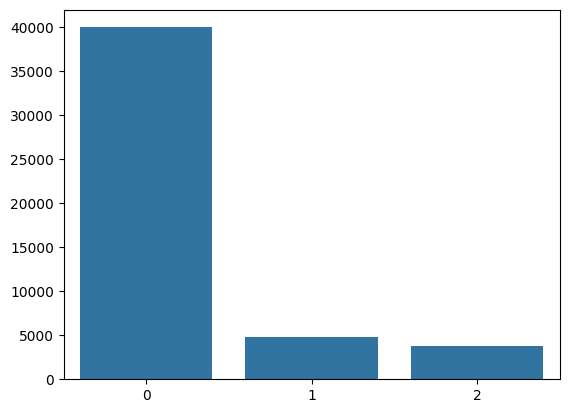

In [53]:
len(snr_labels) #ok, length matches

counts = {0:0, 1:0, 2:0}
for elem in snr_labels:
    if elem == 0:
        counts[0] += 1
    elif elem == 1:
        counts[1] += 1
    elif elem == 2:
        counts[2] += 1

print(counts)
sns.barplot(x=list(counts.keys()), y=list(counts.values()))

##Remember to do analysis on soft labels as well!!!!!

Clustering on Gene Expression 


In [54]:
#fetch df with gene expression data
df.head()
df.shape

(48615, 8460)

Standardization

In [55]:
#df.info()

#based on the plot of mean gean expression vs standard deviation we can see there is a positive relationship between the two and neurons with very different mean and std
#for that reason we scale the data


scaler = StandardScaler()
df_transitory = scaler.fit_transform(df)

df = pd.DataFrame(
    df_transitory,
    columns = df.columns,
    index = df.index
)

In [56]:
# Run PCA. We want to see if we can reasonably reduce the dimensionality of the problem and
#leverage the fact that probably gene expressions are correlated among each other

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(df)


,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

(0.0, 1000.0)

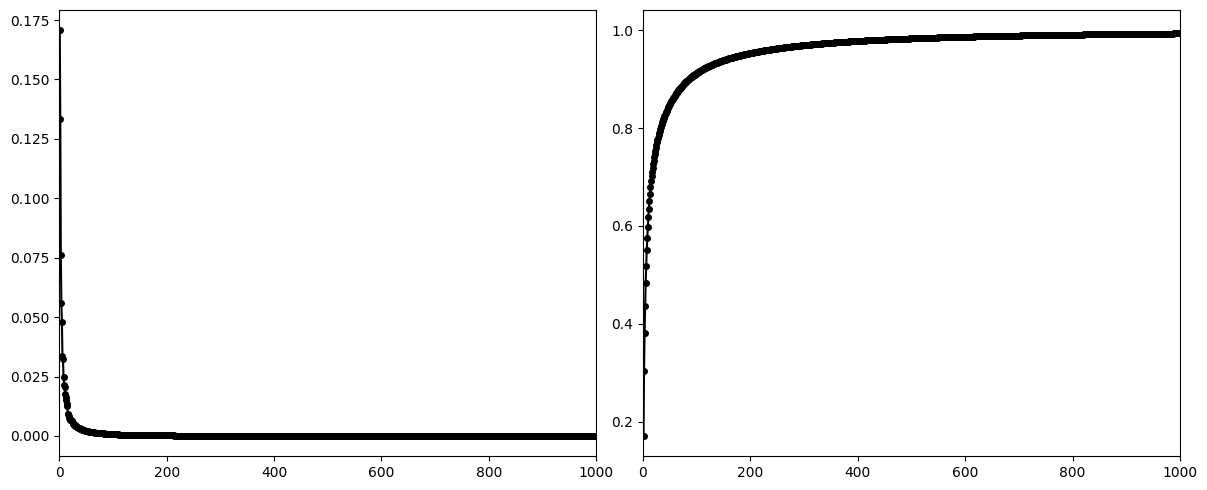

In [57]:
#selecting number of components
explained_var = pca.explained_variance_
explained_var_ratio = pca.explained_variance_ratio_
x = np.linspace(1,len(explained_var),len(explained_var))
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,5))
ax[0].plot(x, explained_var_ratio[0:8640], 'k-', marker = 'o', markersize=4)
ax[1].plot(x,explained_var_ratio.cumsum()[0:8640], 'k-', marker = 'o', markersize=4)
fig.tight_layout()
ax[0].set_xlim(0,1000)
ax[1].set_xlim(0,1000)

In [58]:
#Let's get the new feature matrix
pca2 = PCA(n_components = 150)
low_dim_df_trans = pca2.fit_transform(df)

In [59]:
low_dim_df = pd.DataFrame(
    low_dim_df_trans,
    columns = [f"PCA{i+1}" for i in range(low_dim_df_trans.shape[1])]
)


low_dim_df_array = np.asarray(low_dim_df)

Run differen clustering algorithms

In [60]:
# ###1###
# #Run hierarchical clustering
# hc_avg = hierarchy.linkage(low_dim_df, method='average')
# # Plot the dendrogram
# fig, ax = plt.subplots(1, 1, figsize=(40,20))
# hierarchy.dendrogram(hc_avg, ax=ax, labels=np.asarray(snr_labels),
#                      color_threshold=13, above_threshold_color='black', leaf_font_size = 10)
# plt.show()

In [61]:
# %matplotlib inline
# #Run hierarchical clustering
# hc_comp = hierarchy.linkage(low_dim_df, method='complete', metric="euclidean")
# # Plot the dendrogram
# fig, ax = plt.subplots(1, 1, figsize=(40,20))
# hierarchy.dendrogram(hc_comp, ax=ax, labels=np.asarray(snr_labels),
#                      color_threshold=13, above_threshold_color='black', leaf_font_size = 10)
# plt.show()

In [ ]:
%matplotlib inline
#Run hierarchical clustering
hc_comp = hierarchy.linkage(low_dim_df, method='complete', metric="correlation")
# Plot the dendrogram
fig, ax = plt.subplots(1, 1, figsize=(40,20))
hierarchy.dendrogram(hc_comp, ax=ax,
                     color_threshold=1.4, above_threshold_color='black', leaf_font_size = 10)
plt.show()

In [ ]:
wcv_hierarchical_comp = {}
for i in range(2,7):
    cluster_labels_comp = hierarchy.cut_tree(hc_comp, n_clusters=i)
    cluster_labels_comp = cluster_labels_comp[:, 0]
    wcv_comp_i = compute_wcv(cluster_labels_comp, low_dim_df)
    wcv_hierarchical_comp[i] = wcv_comp_i

For n_clusters = 2 The average silhouette_score is : 0.310477196968917
For n_clusters = 3 The average silhouette_score is : 0.3205462018201716
For n_clusters = 4 The average silhouette_score is : 0.38666445080893447


KeyboardInterrupt: 

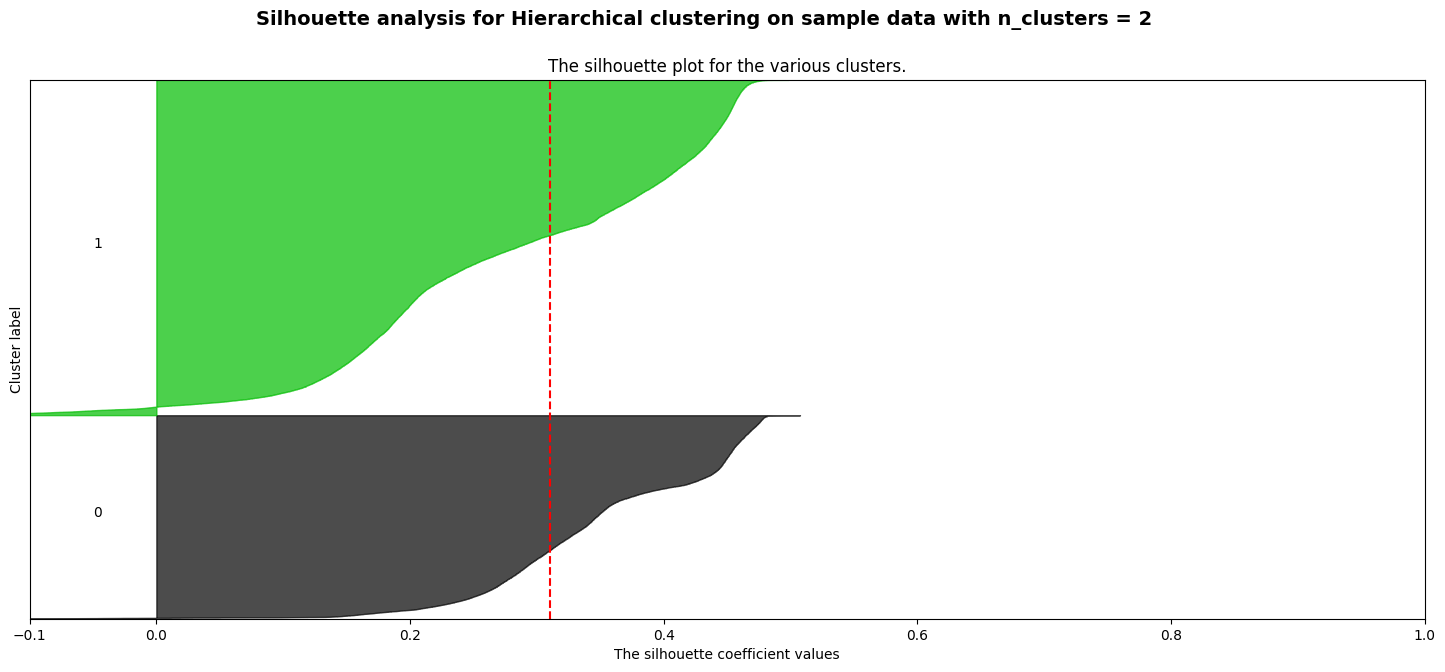

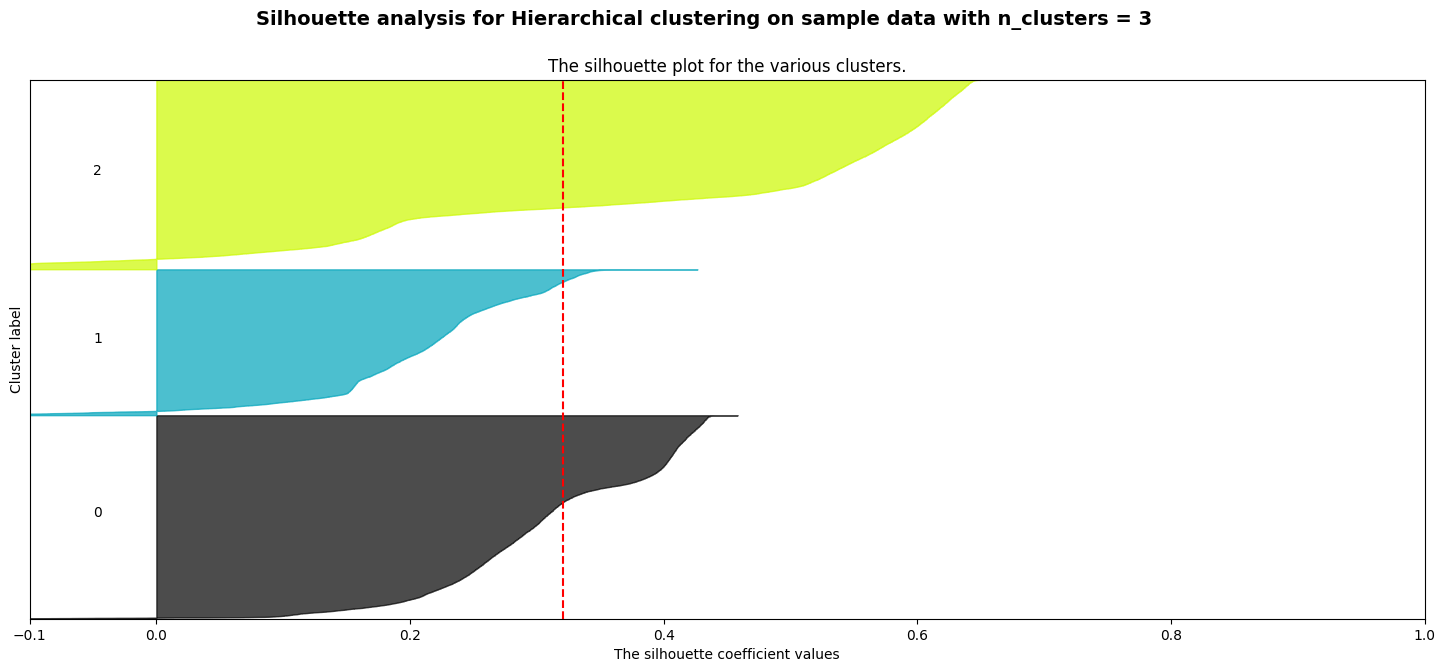

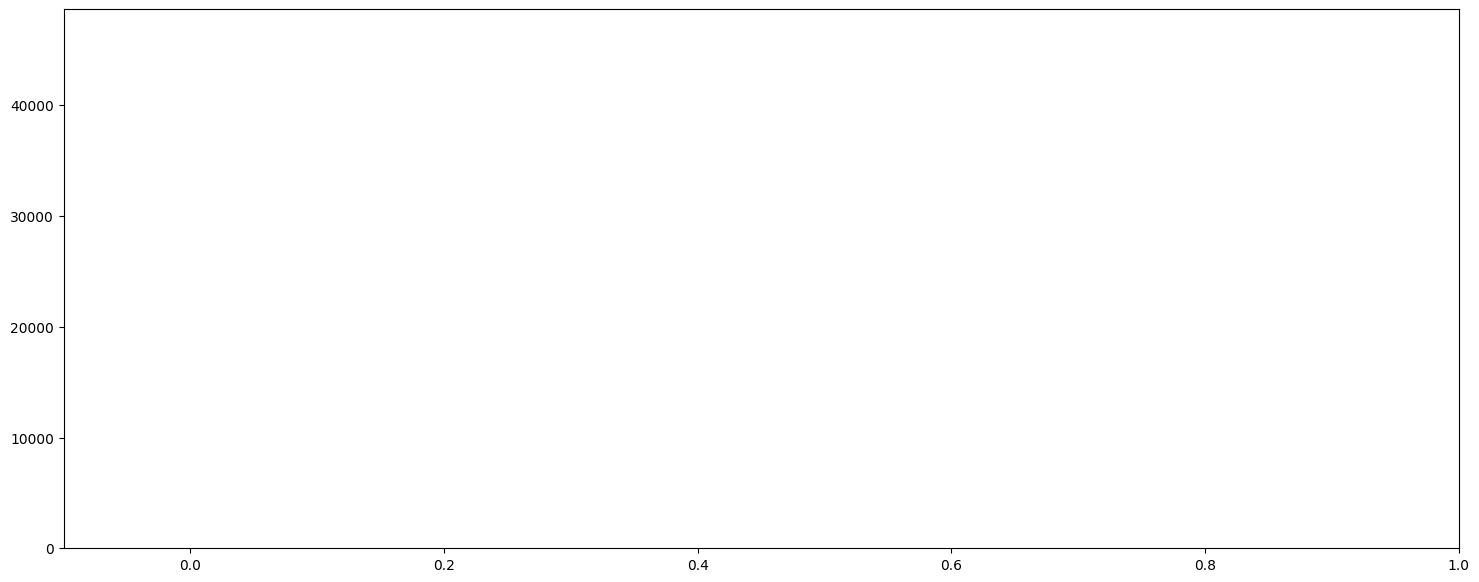

In [ ]:
# Authors: The scikit-learn developers: https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html
# SPDX-License-Identifier: BSD-3-Clause

import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np

from scipy.cluster import hierarchy
from sklearn.metrics import silhouette_samples, silhouette_score

sil_hierarchical_comp = {}
range_n_clusters = [2, 3, 4, 5, 6]
# Compute the hierarchical clustering linkage once
hc_comp = hierarchy.linkage(low_dim_df, method="complete", metric="correlation")

for n_clusters in range_n_clusters:
    # Create a subplot with 1 row and 1 columns
    fig, ax1 = plt.subplots(1, 1)
    fig.set_size_inches(18, 7)

    # The 1st subplot is the silhouette plot
    # The silhouette coefficient can range from -1, 1 but in this example all
    # lie within [-0.1, 1]
    ax1.set_xlim([-0.1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(low_dim_df) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters value and a random generator
    # seed of 10 for reproducibility.
    cluster_labels = hierarchy.cut_tree(hc_comp, n_clusters=n_clusters)
    cluster_labels = cluster_labels[:, 0]

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_comp = silhouette_score(
        low_dim_df,
        cluster_labels,
        metric="correlation"
    )

    print(
        "For n_clusters =",
        n_clusters,
        "The average silhouette_score is :",
        silhouette_comp,
    )
    sil_hierarchical_comp[n_clusters] = silhouette_comp
    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(
        low_dim_df,
        cluster_labels,
        metric="correlation"
    )

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_comp, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    plt.suptitle(
        "Silhouette analysis for Hierarchical clustering on sample data with n_clusters = %d"
        % n_clusters,
        fontsize=14,
        fontweight="bold",
    )

plt.show()

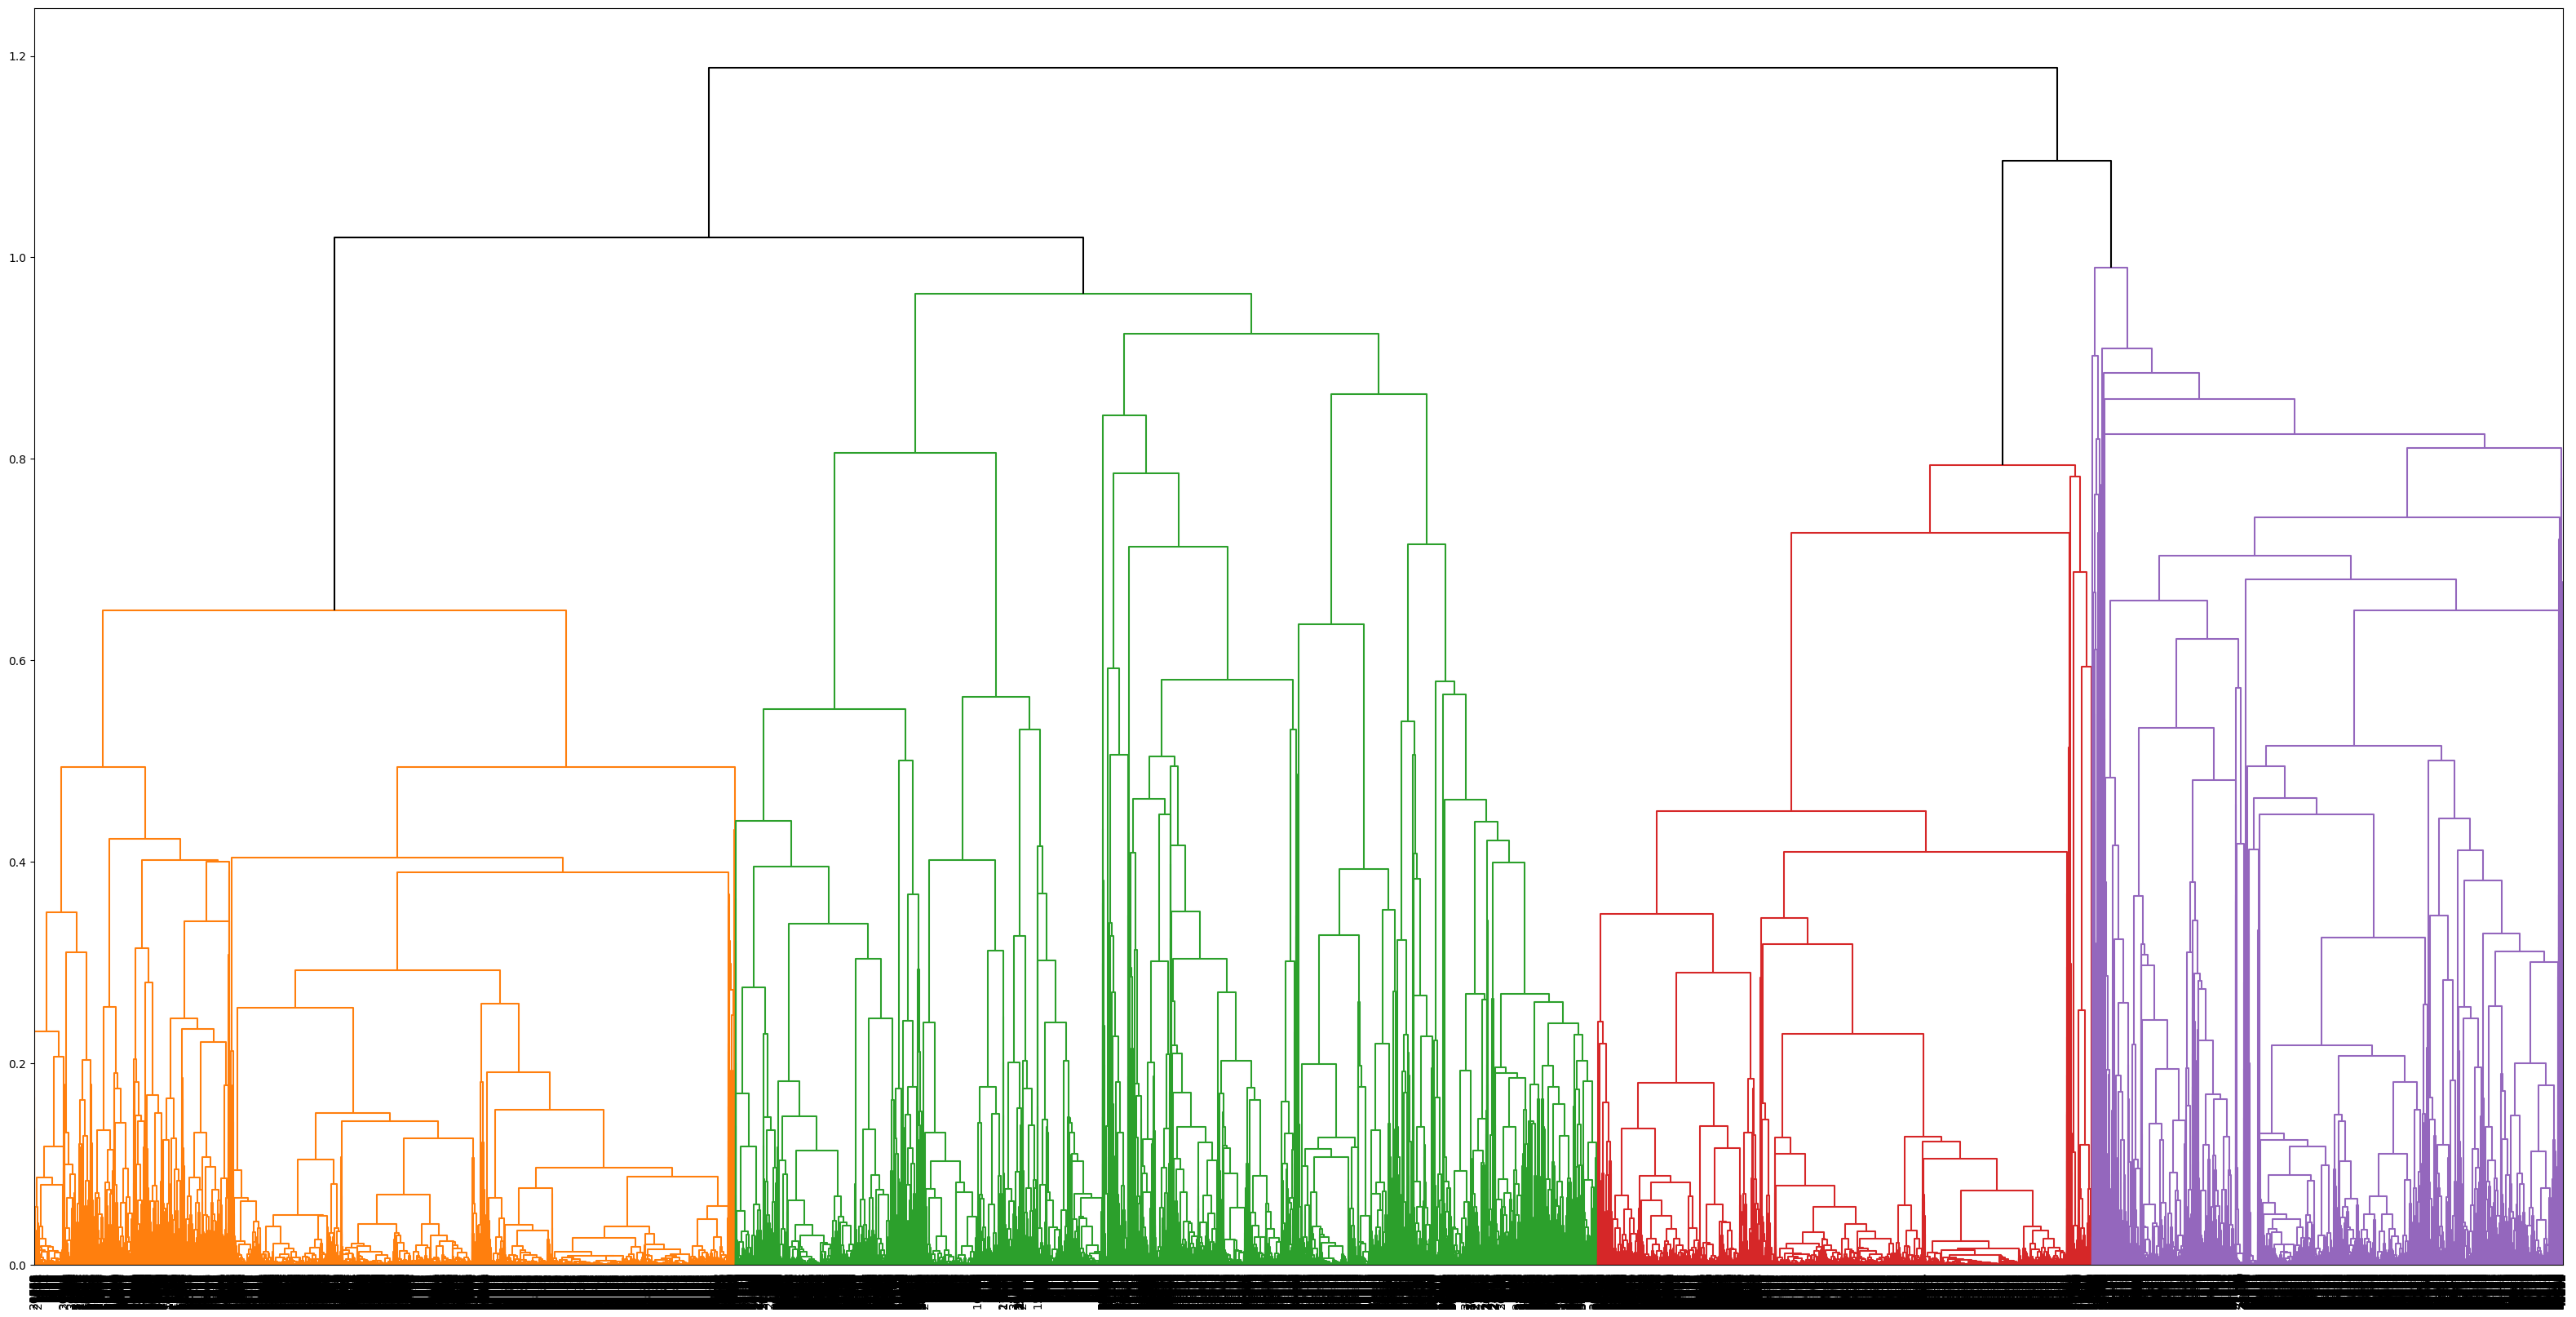

In [ ]:
%matplotlib inline
#Run hierarchical clustering
hc_avg = hierarchy.linkage(low_dim_df, method='average', metric="correlation")
# Plot the dendrogram
fig, ax = plt.subplots(1, 1, figsize=(40,20))
hierarchy.dendrogram(hc_avg, ax=ax,
                     color_threshold=1, above_threshold_color='black', leaf_font_size = 10)
plt.show()

In [ ]:
wcv_hierarchical_avg = {}
for i in range(2,7):
    cluster_labels_avg = hierarchy.cut_tree(hc_avg, n_clusters=i)
    cluster_labels_avg = cluster_labels_avg[:, 0]
    wcv_avg_i = compute_wcv(cluster_labels_avg, low_dim_df)
    wcv_hierarchical_avg[i] = wcv_avg_i

In [ ]:
# Authors: The scikit-learn developers: https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html
# SPDX-License-Identifier: BSD-3-Clause

import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np

from scipy.cluster import hierarchy
from sklearn.metrics import silhouette_samples, silhouette_score

sil_hierarchical_avg = {}
range_n_clusters = [2, 3, 4, 5, 6]
# Compute the hierarchical clustering linkage once
hc_avg = hierarchy.linkage(low_dim_df, method="average", metric="correlation")

for n_clusters in range_n_clusters:
    # Create a subplot with 1 row and 1 columns
    fig, ax1 = plt.subplots(1, 1)
    fig.set_size_inches(18, 7)

    # The 1st subplot is the silhouette plot
    # The silhouette coefficient can range from -1, 1 but in this example all
    # lie within [-0.1, 1]
    ax1.set_xlim([-0.1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(low_dim_df) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters value and a random generator
    # seed of 10 for reproducibility.
    cluster_labels = hierarchy.cut_tree(hc_avg, n_clusters=n_clusters)
    cluster_labels = cluster_labels[:, 0]

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_avg = silhouette_score(
        low_dim_df,
        cluster_labels,
        metric="correlation"
    )

    print(
        "For n_clusters =",
        n_clusters,
        "The average silhouette_score is :",
        silhouette_avg,
    )
    sil_hierarchical_avg[n_clusters] = silhouette_avg
    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(
        low_dim_df,
        cluster_labels,
        metric="correlation"
    )

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    plt.suptitle(
        "Silhouette analysis for Hierarchical clustering on sample data with n_clusters = %d"
        % n_clusters,
        fontsize=14,
        fontweight="bold",
    )

plt.show()

K++

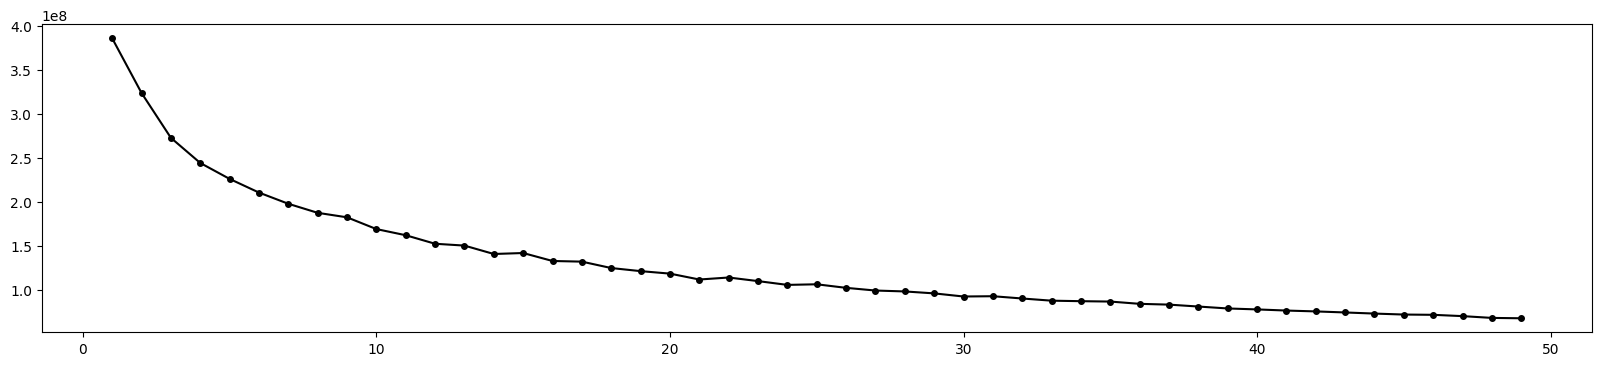

In [ ]:
n_k = np.arange(1,50,1)
rs = 0
wcv = []
fig, ax = plt.subplots(1,1,figsize=(20,4))
for n in range(n_k.shape[0]):
    kmeans_n = KMeans(n_clusters = n_k[n], init = 'k-means++', n_init = 10, random_state=rs).fit(low_dim_df)
    wcv.append(kmeans_n.inertia_)
ax.plot(n_k, wcv, 'k-', marker = 'o', markersize=4)

In [ ]:
wcv_kmeans = {}
for i in range(2,7):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', n_init = 15, random_state=rs).fit(low_dim_df)
    wcv_kmeans_i = kmeans.inertia_
    wcv_kmeans[i] = wcv_kmeans_i

cluster_labels_kmeans = kmeans.labels_

In [ ]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_samples, silhouette_score

# Generating the sample data from make_blobs
# This particular setting has one distinct cluster and 3 clusters placed close
# together.
range_n_clusters = [2, 3, 4, 5, 6]
sil_kmeans = {}

for n_clusters in range_n_clusters:
    # Create a subplot with 1 row and 2 columns
    fig, ax1 = plt.subplots(1, 1)
    fig.set_size_inches(18, 7)

    # The 1st subplot is the silhouette plot
    # The silhouette coefficient can range from -1, 1 but in this example all
    # lie within [-0.1, 1]
    ax1.set_xlim([-0.1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(low_dim_df) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters value and a random generator
    # seed of 10 for reproducibility.
    clusterer = KMeans(n_clusters = n_clusters, init = 'k-means++', n_init = 15, random_state=rs)
    cluster_labels = clusterer.fit_predict(low_dim_df)

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_avg = silhouette_score(low_dim_df, cluster_labels)
    print(
        "For n_clusters =",
        n_clusters,
        "The average silhouette_score is :",
        silhouette_avg,
    )
    sil_kmeans[n_clusters] = silhouette_avg
    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(low_dim_df, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    plt.suptitle(
        "Silhouette analysis for KMeans clustering on sample data with n_clusters = %d"
        % n_clusters,
        fontsize=14,
        fontweight="bold",
    )

plt.show()

Summary

In [ ]:
summary_table = pd.DataFrame(
    {
        (2, "WCV"): [
            wcv_hierarchical_comp[2],
            wcv_hierarchical_avg[2],
            wcv_kmeans[2],
        ],
        (2, "Silhouette"): [
            sil_hierarchical_comp[2],
            sil_hierarchical_avg[2],
            sil_kmeans[2],
        ],

        (3, "WCV"): [
            wcv_hierarchical_comp[3],
            wcv_hierarchical_avg[3],
            wcv_kmeans[3],
        ],
        (3, "Silhouette"): [
            sil_hierarchical_comp[3],
            sil_hierarchical_avg[3],
            sil_kmeans[3],
        ],

        (4, "WCV"): [
            wcv_hierarchical_comp[4],
            wcv_hierarchical_avg[4],
            wcv_kmeans[4],
        ],
        (4, "Silhouette"): [
            sil_hierarchical_comp[4],
            sil_hierarchical_avg[4],
            sil_kmeans[4],
        ],

        (5, "WCV"): [
            wcv_hierarchical_comp[5],
            wcv_hierarchical_avg[5],
            wcv_kmeans[5],
        ],
        (5, "Silhouette"): [
            sil_hierarchical_comp[5],
            sil_hierarchical_avg[5],
            sil_kmeans[5],
        ],

        (6, "WCV"): [
            wcv_hierarchical_comp[6],
            wcv_hierarchical_avg[6],
            wcv_kmeans[6],
        ],
        (6, "Silhouette"): [
            sil_hierarchical_comp[6],
            sil_hierarchical_avg[6],
            sil_kmeans[6],
        ],
    },
    index=["Hierarchical_complete","Hierarchical_average", "KMeans++"]
)

summary_table.columns.names = ["n_clusters", "Metric"]

summary_table

NameError: name 'sil_hierarchical_comp' is not defined